# Running Monte Carlo Simulations with MC Sim

## Overview

In the course Chem 280, we developed the foundational code for running Monte Carlo simulations focused on Lennard-Jones fluids. 
This code has now been encapsulated in a Python package named `mcsim`.

For those in need of a refresher, Monte Carlo simulation is a statistical technique used to model complex systems. 
In the context of a Lennard-Jones fluid, we begin by generating an initial configuration, or set of coordinates, that represents a system of atoms placed in a cubic box with periodic boundary conditions. 
Further configurations are then generated by proposing random moves for individual particles. Whether these new configurations are accepted depends on the change in system energy as calculated by the Lennard-Jones potential, along with a probabilistic factor for higher-energy states. 
This is an extremely simplified overview, but this is just a refresher!

The configurations generated can then be analyzed to determine various system properties like pressure or structural information. 
One type of analysis is the Radial Distribution Function (RDF). 
This lesson guide will walk you through how to use the `mcsim` package to perform and analyze such simulations.

This notebook will generate some programming concepts you haven't seen before, but don't worry, we will learn about them in Chem 274A. 
Try not to get bogged down in the lines of code, 
but instead look at how we would run a simulation and the simulation results. We are happy to answer any coding questions you have, however.

### Objectives
1. Gain a deeper understanding of the Radial Distribution Function and its role in molecular simulations.
2. Set up and run molecular simulations.
3. Learn to run and analyze simulatoins with different input parameters and make comparative analyses of the results.

### Part 0: Package installation

Use the `Makefile` in the reposistory to install the `mcsim` package.
Make sure you set up this notebook to run with the `chem274A_lab1` kernel after you have performed the set-up steps.

## Part 1: The Radial Distribution Function (RDF)

The Radial Distribution Function (RDF) is an important concept in molecular simulations, and allows quantitative analysis of spatial arrangement of atoms. 
The RDF tells us about how atom density varies as a function of distance from a reference atom.
For a more detailed explaination, see [this webpage](https://en.wikibooks.org/wiki/Molecular_Simulation/Radial_Distribution_Functions).

Notably, different phases of matter (solid, liquid, gas) exhibit different shaped RDFs, example shown below:

<img src="rdf_argon_phases.png"  style="width:400px">

In this lab, you will use the RDF to evaluate the structure of the Lennard Jones fluid under different conditions.

## Part 2: Steps for Running a Simulation

The next few cells walk you through running a simultaion with the `mcsim` package (included in this repository).
After you have been walked through the steps, there are exercises for you to complete at the end of the notebook where you will 
vary your simulation parameters and compare the results.

Molecular simulations are typically done following a particular procedure, outlined below.
This will also be relevant for our next lab, where we will run molecular dynamics simulations.

### Step 1: Import Required Packages
Before running any simulation, you'll need to import the relevant Python packages, including `mcsim`.

### Step 2: Set System Parameters
For every simulation, a system parameters, such as the number of atoms in the system, the density, and the temperature. This is information about our molecular system (not the simulation itself).

### Step 3: Set Simulation Parameters
Additional settings specific to the simulation need to be defined. These include:
  - **Number of Steps**: This specifies the number of trial moves for generating configurations. These trial moves may or may not be accepted, based on the resulting system energy.
  - **Simulation Cutoff**: This sets the maximum distance over which non-bonded interactions are calculated.
  - **Maximum Particle Displacement**: This is the upper limit on how far a particle may be moved during each configuration trial.

### Step 4: Equilibration Simulation
When performing a molecular simulation an "equilibration simulation" is always performed to allow the system energies to stabilize. During equilibration, the system evolves according to the simulation type, but this simulation will not be analyzed for data.

### Step 5: Production Simulation
Once equilibration is complete, you can proceed to the production simulation. This is the phase where data are collected for analysis, and it should only be run once the system has reached an equilibrium state (the system energy has stabilized).

### Step 6: Analyze the simulation
After you have run the simulation, you will analyze the generated coordinates. This can involve looking at the energies and analyzing the generated coordinates.



## Directions
Execute the following cells to perform a simulation with one set of conditions.
At the end, there is a cell containing questions and exercises. 
Go through one simulation (execute all cells) until you arrive at the exercises. 
Then, modify the code in previous cells in order to perform the exercises and answer the questions.

### Step 1: Import Required Packages

In [1]:
# All of the imports we will need in this notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy

# Import the needed functions from our mcsim package.
from mcsim import run_simulation, generate_cubic_lattice, generate_random_coordinates
from mcsim.analysis import time_average_rdf

### Step 2: Set System Parameters

In [79]:
# Set system parameters - you will modify this
num_atoms = 500
reduced_temperature = 0.9
density = 0.9

### Step 3: Set Simulation Parameters

In [80]:
# Set simulation parameters - you will modify this
num_steps = 100000
max_displacement = 0.1 
cutoff = 3
freq = 1000


# Generate the initial configuration
atomic_coordinates, box_length = generate_random_coordinates(num_atoms, density)

# Convert to numpy array
atomic_coordinates = np.array(atomic_coordinates)

### Step 4: Equilibration Simulation

In [81]:
# Run an equilibration simulation
equilibration_coords = run_simulation(deepcopy(atomic_coordinates), 
                                              box_length, cutoff, 
                                              reduced_temperature, 
                                              num_steps, freq=freq, filename="equilibration.csv")

Step Number,Energy per particle,Pressure
0, 40717290.270593904, 146585500.74288607
1000, 21251449.480505373, 76506527.51495102
2000, 20959910.91723882, 75456723.6695698
3000, 28203.087779357786, 101692.37942701761
4000, 4233.566485086986, 15337.152327274453
5000, 390.14717436963116, 1471.406524348094
6000, 249.3943148635849, 953.490482778923
7000, 87.33115016364158, 363.0745378009731
8000, 36.47769039047287, 175.14328250119377
9000, 25.65741543701084, 133.3357438260692
10000, 17.952581127662558, 103.1594079946399
11000, 9.668042507084198, 71.11101244509778
12000, 5.940794306803628, 56.18124787230873
13000, 3.422307817528914, 45.985940433083826
14000, 1.5167004894821021, 38.25535726399358
15000, -0.00836233998443482, 31.857970365593953
16000, -1.058711392945957, 27.48347146475165
17000, -1.7474978262957697, 24.476613460208764
18000, -2.3431173996908545, 21.88801972108447
19000, -2.7942135356234408, 19.81944161418121
20000, -3.2111620908079708, 18.001495925589577
21000, -3.59528104558656

Now that we've run our equilibration, we want to examine the energies to make sure our system has reached a stable state. Our equilibration wrote a file called "equilibration.csv". We will read it using pandas and plot it using matplotlib.

In [82]:
# we will use pandas read_csv function - very commonly used in Python for data science
equil = pd.read_csv("equilibration.csv")
equil.tail() # view the first five rows

,Step Number,Energy per particle,Pressure
95,95000,-6.056585,3.847155
96,96000,-6.028242,3.992095
97,97000,-5.995360,4.095789
98,98000,-6.001327,4.058444
99,99000,-6.064572,3.794161


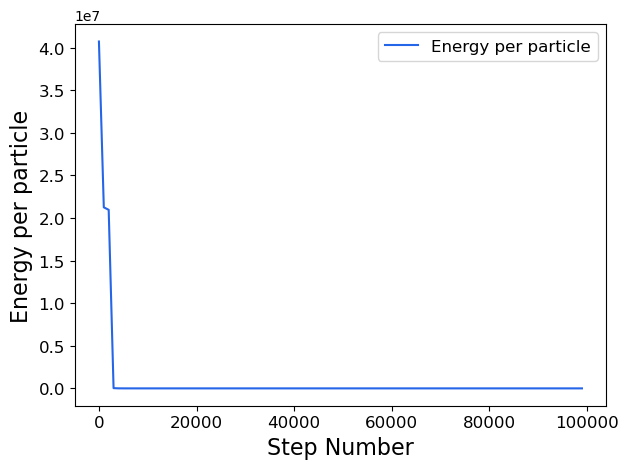

In [83]:
## Some code for making a pretty plot with matplotlib

fig, ax = plt.subplots()
ax.plot("Step Number", "Energy per particle", data=equil, color="#2565E8")
ax.set_ylabel('Energy per particle', fontsize=16)
ax.set_xlabel('Step Number', fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=12)
ax.legend(fontsize=12)
fig.tight_layout()

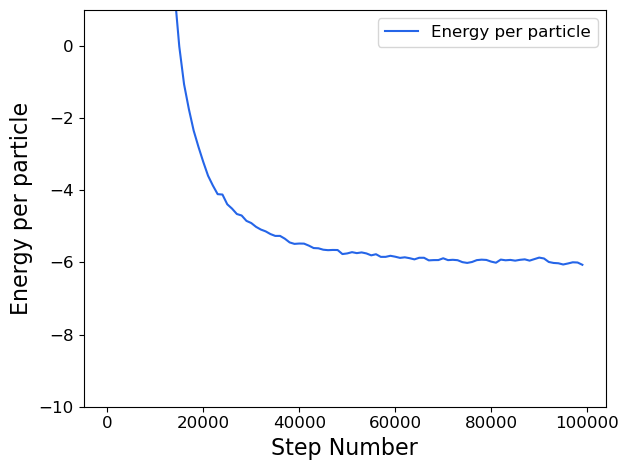

In [84]:
# Modify the y axis range so we can better see our results.

fig, ax = plt.subplots()
ax.plot("Step Number", "Energy per particle", data=equil, color="#2565E8")
ax.set_ylabel('Energy per particle', fontsize=16)
ax.set_xlabel('Step Number', fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=12)
ax.set_ylim(-10,1)
ax.legend(fontsize=12)
fig.tight_layout()

### Step 5: Production Simulation

After our system as reached a steady energy, we are ready to run simulations which we will analyze. These are called "production" simulations.

In [85]:
# Set simulation parameters
num_steps = 100000
max_displacement = 0.1 
cutoff = 3
freq = 1000

# One way to keep several different files programmatically is to use a variable file name.
# we create a variable file name using the system parameters.
# This way, you can modify your simulation notebook and rerun without fear of
# losing results you already have!
filename = f"T_{reduced_temperature}_density_{density}_nsteps_{num_steps}".replace(".", "p")

# Production

last_frame = deepcopy(equilibration_coords[-1])
    
production_coordinates = run_simulation(last_frame, box_length, 
                                        cutoff, reduced_temperature, 
                                        num_steps, freq=freq, filename=f"production_{filename}.csv")

Step Number,Energy per particle,Pressure
0, -6.064260927191822, 3.7954633107077975
1000, -6.012704683006377, 3.9956596100077646
2000, -6.04777592196425, 3.839472228334907
3000, -6.072921839714907, 3.7156373453010447
4000, -6.065406727342932, 3.7582234963770293
5000, -6.120487407949881, 3.470740559136795
6000, -6.049134992856326, 3.821749151775901
7000, -6.107362363140203, 3.5308408951937214
8000, -6.067067707300692, 3.669174337999076
9000, -6.042104895608149, 3.7585208133027668
10000, -6.074117625941796, 3.6533871606106385
11000, -6.050241574461363, 3.7847816841794946
12000, -6.052185545970392, 3.7586613244049407
13000, -6.017338025313493, 3.9710092489642963
14000, -6.016960772711107, 3.918341597381996
15000, -6.068200095700814, 3.6477197369037286
16000, -6.04191930619279, 3.798253722028548
17000, -6.09345647004511, 3.598957305477957
18000, -6.0867593318480955, 3.6234594404733533
19000, -6.11911311328719, 3.430683842010438
20000, -6.098244777911462, 3.47504829428038
21000, -6.109444132

We will analyze our configurations to determine the radial distribution function. The radial distribution function has particular shapes depending on the phase (solid, liquid, gas) so the RDF helps us to determine the phase of our material.

### Step 6: Analyze the simulation
Our `mcsim` package contains an analysis function called `time_average_rdf`. 
This analyzes all of the saved configurations for radial distribution function, and averages across frames.

In [86]:
low_temp_rdf = time_average_rdf(production_coordinates, box_length, num_atoms, box_length/2)

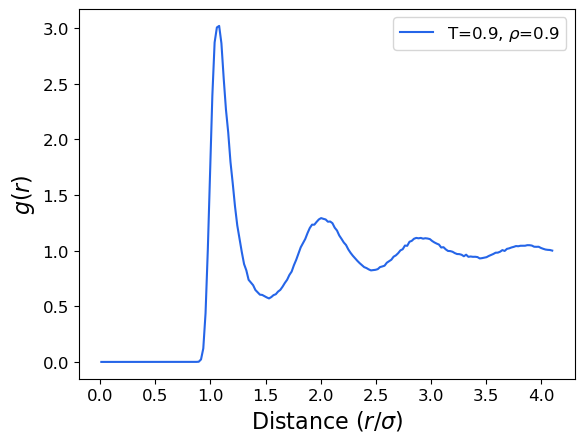

In [90]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(low_temp_rdf[0], low_temp_rdf[1], label=rf'T={reduced_temperature}, $\rho$={density}', color="#2565E8")
ax.set_ylabel(r'$g(r)$', fontsize=16)
ax.set_xlabel(r'Distance ($r/\sigma$)', fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=12)
ax.legend(fontsize=12)

plt.savefig(f'{filename}.png', dpi=300)

## Exercises

Now that you have run and analyzed one simulation using `mcsim`, complete the following exercises to compare results under varying simulation conditions. In these exercises, you will explore the impact of system temperature and density, as well as the influence of equilibration length on the simulation results. This notebook is designed so that you'll only need to modify the system and simulation parameters in Steps 2 and 3.

The `run_simulation` command returns a list of generated configurations, and the simulation outputs the step number, system energy, and system pressure to a CSV file.

### (1) Initial Simulation

The parameters for the simulation you just ran were:
- num_atoms = 500
- reduced_temperature = 0.9
- density = 0.9
- 100000 steps for equilibration (freq = 1000)
- 100000 steps for production (freq = 10000)

1. What trends did you observe in the energy during the equilibration run?


**ANSWER** The energy starts very high, but levels off to a value around -6 per particle. This happens because particularly when starting from a random configuration you might have overlapping particles (very high energy). As the system moves particles, it gets rid of these bad contacts very quickly as moving them will usually result in a decrease in energy. If you happened to observe a higher energy, or didn't see leveling, your initial random configuration was so far from equilibrium that it didn't reach a steady state in the number of steps. You could try a different starting configuration or run the simulation for longer. 

2. Describe the Radial Distribution Function (RDF) you observed. How many peaks are there? How far apart are they? Do the peaks vary in height?


**ANSWER** The observed RDF has smooth peaks. The first one is the highest and occurs around approximately 1 sigma (one particle size). This indicates that the particles are close to touching one another in the first solvation shell. Peaks occur around intervals of 1 sigma and decrease in size.

3. Does the RDF most closely resemble that of a solid, liquid, or gas?

**ANSWER** It resembles a liquid.

<img src="T_0p9_density_0p9_nsteps_100000.png" width="500">


### (2) Short Equilibration and Simulation

Run a simulation with the following parameters:
- num_atoms = 500
- reduced_temperature = 0.9
- density = 0.9
- 10 steps for equilibration (freq = 1)
- 1000 steps for production (freq = 100)

1. What trends did you observe in the energy during the equilibration run?

**ANSWER** - The energy is very high and decreases a few times in a "step" fashion. This is because when we use `freq=1` we see when moves are accepted or rejected. At the end of equilibration (only 10 steps), the energy is still very high. It will vary from person to person, but it will likely be above the order of 10E10. 

2. Describe the RDF you observed. How many peaks are there? How far apart are they? Do the peaks vary in height?

**ANSWER** - The RDF is very disordered, but there is a large peak close to 0 (much less than 1 sigma). This indicates a large number of overlapping particles and would not physically occur in real life.

3. What differences do you notice between the results of the "Initial Simulation" and this "Short Equilibration and Simulation"? Why do you think these differences occur?

These differences occur because the equilibration was not long enough to eliminate bad contacts.

<img src="T_0p9_density_0p9_nsteps_1000.png" width="500">


### (3) Varying Simulation Parameters - Effect of Density

Repeat exercise (1) with a system density of `0.009`.

1. Describe the RDF you observed. How many peaks are there? How far apart are they? Do the peaks vary in height?

**ANSWER** There is only on distinguishable peak. It is much farther away than at lower density, around 2.5 sigma.

2. Does the RDF most closely resemble that of a solid, liquid, or gas?

**ANSWER** It most closely resembles a gas.

<img src="T_0p9_density_0p009_nsteps_100000.png" width="500">


### (4) Varying Simulation Parameters - Effect of Temperature

Repeat exercise (1) with a system temperature of `1.5`.

1. Describe the RDF you observed. How many peaks are there? How far apart are they? Do the peaks vary in height?

**ANSWER** The RDF looks very similar to (1) except that if you examine closely, you will typically find the peaks are more spread out on the x axis and not quite as high on the z-axis for higher temperatures. This is easiest to see by comparing the scale of the y axis in both plots and would be the most easy to see by plotting the two lines on the same graph. 

2. Does the RDF most closely resemble that of a solid, liquid, or gas?

**ANSWER** It resembles a liquid.

<img src="T_1p5_density_0p9_nsteps_100000.png" width="500">

<img src="two_temps.png" width="500">



### Challenges

5. Try exercises (1) and (2) again, but use `generate_cubic_lattice` instead of `generate_random_coordinates`. Do you notice any differences in the results?
6. Plot two RDFs on the same plot. This will require you to save the RDFs under different variable names and to rename the saved figure.

Please record your answers and observations in a `README.md` file in this repository.
